<a href="https://colab.research.google.com/github/Rajukc45/Capstone-project/blob/main/week5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install required libraries
!pip install xgboost imbalanced-learn

# Imports
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

In [2]:
from google.colab import files
uploaded = files.upload()
import pandas as pd

df = pd.read_csv("creditcard.csv")
df.head()

Saving creditcard.csv to creditcard.csv


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
print(df.info())
print(df['Class'].value_counts())  # Check imbalance

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16383 entries, 0 to 16382
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    16383 non-null  int64  
 1   V1      16383 non-null  float64
 2   V2      16383 non-null  float64
 3   V3      16383 non-null  float64
 4   V4      16383 non-null  float64
 5   V5      16383 non-null  float64
 6   V6      16383 non-null  float64
 7   V7      16383 non-null  float64
 8   V8      16383 non-null  float64
 9   V9      16383 non-null  float64
 10  V10     16383 non-null  float64
 11  V11     16383 non-null  float64
 12  V12     16383 non-null  float64
 13  V13     16383 non-null  float64
 14  V14     16383 non-null  float64
 15  V15     16383 non-null  float64
 16  V16     16383 non-null  float64
 17  V17     16383 non-null  float64
 18  V18     16383 non-null  float64
 19  V19     16383 non-null  float64
 20  V20     16383 non-null  float64
 21  V21     16383 non-null  float64
 22

In [5]:
# Separate features and target
X = df.drop("Class", axis=1)
y = df["Class"]

# Scale features (important for LR, SVM)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split (stratified for imbalance)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)


In [6]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", pd.Series(y_train_res).value_counts())

Before SMOTE: Class
0    13048
1       58
Name: count, dtype: int64
After SMOTE: Class
0    13048
1    13048
Name: count, dtype: int64


In [8]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(probability=True),
    "XGBoost": XGBClassifier(eval_metric='logloss', use_label_encoder=False)
}

In [9]:
trained_models = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_res, y_train_res)
    trained_models[name] = model


Training Logistic Regression...

Training Random Forest...

Training SVM...

Training XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [21:58:26] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [10]:
results = {}

for name, model in trained_models.items():
    print(f"\n{name} Evaluation:")

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))

    auc = roc_auc_score(y_test, y_prob)
    print("AUC-ROC:", auc)

    results[name] = auc


Logistic Regression Evaluation:
[[3250   12]
 [   4   11]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3262
           1       0.48      0.73      0.58        15

    accuracy                           1.00      3277
   macro avg       0.74      0.86      0.79      3277
weighted avg       1.00      1.00      1.00      3277

AUC-ROC: 0.9320253423257715

Random Forest Evaluation:
[[3259    3]
 [   4   11]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3262
           1       0.79      0.73      0.76        15

    accuracy                           1.00      3277
   macro avg       0.89      0.87      0.88      3277
weighted avg       1.00      1.00      1.00      3277

AUC-ROC: 0.9973840179848763

SVM Evaluation:
[[3247   15]
 [   4   11]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3262
           1       0.42

In [11]:
print("\nModel Comparison (AUC-ROC):")
for name, score in results.items():
    print(f"{name}: {score:.4f}")

best_model_name = max(results, key=results.get)
print("\nBest Model:", best_model_name)


Model Comparison (AUC-ROC):
Logistic Regression: 0.9320
Random Forest: 0.9974
SVM: 0.9589
XGBoost: 0.9933

Best Model: Random Forest


In [12]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0]
}

xgb = XGBClassifier(eval_metric='logloss', use_label_encoder=False)

grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    verbose=1,
    n_jobs=-1
)

grid.fit(X_train_res, y_train_res)

print("Best Parameters:", grid.best_params_)
best_model = grid.best_estimator_

Fitting 3 folds for each of 24 candidates, totalling 72 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [22:01:10] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}


In [13]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("\nFinal Model Evaluation:")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("Final AUC-ROC:", roc_auc_score(y_test, y_prob))


Final Model Evaluation:
[[3258    4]
 [   3   12]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3262
           1       0.75      0.80      0.77        15

    accuracy                           1.00      3277
   macro avg       0.87      0.90      0.89      3277
weighted avg       1.00      1.00      1.00      3277

Final AUC-ROC: 0.9965665236051502


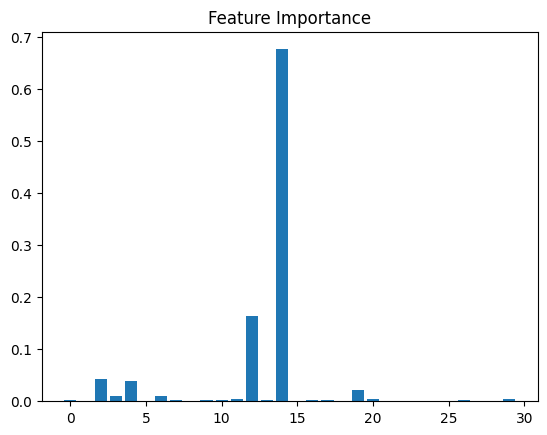

In [14]:
import matplotlib.pyplot as plt

importance = best_model.feature_importances_

plt.bar(range(len(importance)), importance)
plt.title("Feature Importance")
plt.show()

In [15]:
import joblib

joblib.dump(best_model, "fraud_detection_model.pkl")

['fraud_detection_model.pkl']

In [16]:
def predict_transaction(model, scaler, new_data):
    new_data_scaled = scaler.transform(new_data)
    prediction = model.predict(new_data_scaled)
    probability = model.predict_proba(new_data_scaled)[:, 1]
    return prediction, probability

# Example (use real values)
sample = X.iloc[:1]
pred, prob = predict_transaction(best_model, scaler, sample)

print("Prediction:", pred)
print("Fraud Probability:", prob)

Prediction: [0]
Fraud Probability: [3.929154e-06]
